# Router

#### Review
We built a graph that uses `messages` as state and a chat model with bound tools.

We saw that the graph can:

Return a tool call
Return a natural language response

#### Goals
We can think of this as a router, where the chat model routes between a direct response or a tool call based upon the user input.

This is a simple example of an agent, where the LLM is directing the control flow either by calling a tool or just responding directly.

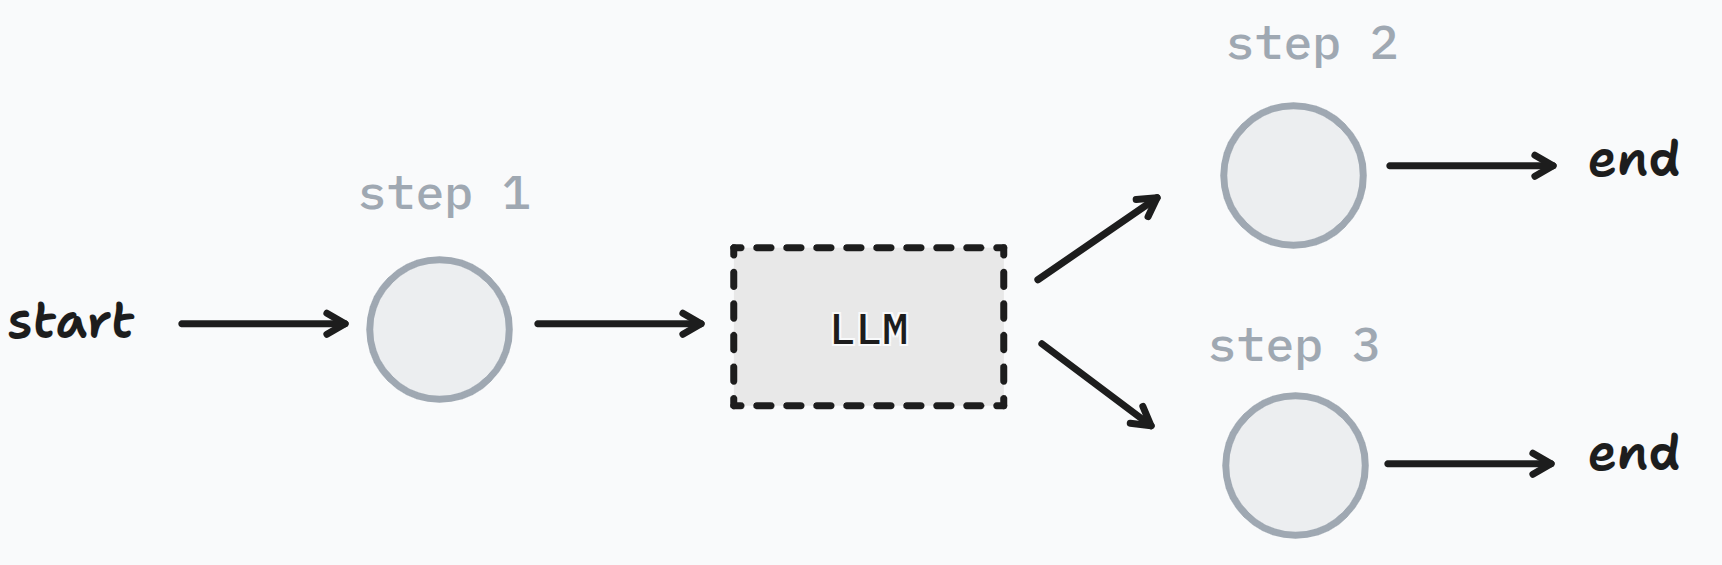

Let's extend our graph to work with either output!

For this, we can use two ideas:

(1) Add a node that will call our tool.

(2) Add a conditional edge that will look at the chat model output, and route to our tool calling node or simply end if no tool call is performed.

In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI

def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# Chat Model
llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash")
# Chat model with bound tools
llm_with_tools = llm.bind_tools([multiply])

We use the [built-in `ToolNode`](https://langchain-ai.github.io/langgraph/reference/agents/#toolnode) and simply pass a list of our tools to initialize it.

We use the [built-in `tools_condition`](https://langchain-ai.github.io/langgraph/reference/agents/#tools_condition) as our conditional edge.

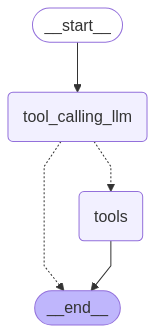

In [2]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Node
def tool_calling_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode([multiply]))
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [4]:
print(graph.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	tool_calling_llm(tool_calling_llm)
	tools(tools)
	__end__([<p>__end__</p>]):::last
	__start__ --> tool_calling_llm;
	tool_calling_llm -.-> __end__;
	tool_calling_llm -.-> tools;
	tools --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [5]:
from langchain_core.messages import HumanMessage
messages = [HumanMessage(content="Hello, what is 2 multiplied by 2?")]

In [6]:
messages = graph.invoke({"messages": messages})

In [7]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello, what is 2 multiplied by 2?
================================== Ai Message ==================================
Tool Calls:
  multiply (3f9e01df-a306-4635-a2b7-bd9d7fa21c94)
 Call ID: 3f9e01df-a306-4635-a2b7-bd9d7fa21c94
  Args:
    a: 2.0
    b: 2.0
================================= Tool Message =================================
Name: multiply

4
